# Eksperimen Sistem Machine Learning — Credit Scoring
**Nama:** JonathanBenedictSirait  
**Proyek:** Membangun Sistem Machine Learning (Dicoding)

Notebook ini adalah tahap **eksperimen manual**. Di sini kita melakukan:
1. **Data Loading** — memuat dataset mentah.
2. **Exploratory Data Analysis (EDA)** — memahami isi data.
3. **Data Preprocessing** — membersihkan & menyiapkan data agar siap dilatih.

Langkah-langkah yang terbukti berhasil di sini nantinya kita **otomatisasikan** ke file `automate_JonathanBenedictSirait.py`.

> **Studi kasus:** Memprediksi apakah seorang peminjam akan **gagal bayar (default)** — kolom target `loan_status` (1 = gagal bayar, 0 = lancar).

## 1. Import Library
Memuat semua pustaka yang dibutuhkan sepanjang eksperimen.

In [40]:
# Pustaka dasar untuk manipulasi data & visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pustaka scikit-learn untuk preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

# Pengaturan tampilan agar output rapi
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
np.random.seed(42)   # supaya hasil acak selalu sama (reproducible)

print('Semua library berhasil di-import.')

Semua library berhasil di-import.


## 2. Data Loading
Memuat dataset mentah dari folder `namadataset_raw`. Dataset ini berisi profil peminjam dan status pinjamannya.

In [41]:
# Membaca file CSV mentah ke dalam DataFrame
df = pd.read_csv('../namadataset_raw/credit_scoring_raw.csv')

# Melihat ukuran data: (jumlah baris, jumlah kolom)
print('Ukuran dataset:', df.shape)

# Menampilkan 5 baris pertama untuk melihat bentuk datanya
df.head()

Ukuran dataset: (6030, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,28,25024,MORTGAGE,0.3,HOMEIMPROVEMENT,D,25327,12.97,1.012,N,7,1
1,47,88947,MORTGAGE,1.4,DEBTCONSOLIDATION,E,21066,5.74,0.237,N,21,1
2,45,75037,MORTGAGE,8.0,PERSONAL,A,23888,13.95,0.318,N,4,0
3,28,47600,MORTGAGE,7.5,HOMEIMPROVEMENT,A,5236,9.87,0.110,N,13,0
4,45,46527,OWN,0.9,PERSONAL,A,5754,15.66,0.124,Y,20,0


In [43]:
# Melihat tipe data setiap kolom & jumlah nilai non-null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6030 entries, 0 to 6029
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  6030 non-null   int64  
 1   person_income               6030 non-null   int64  
 2   person_home_ownership       6030 non-null   object 
 3   person_emp_length           5487 non-null   float64
 4   loan_intent                 6030 non-null   object 
 5   loan_grade                  6030 non-null   object 
 6   loan_amnt                   6030 non-null   int64  
 7   loan_int_rate               5668 non-null   float64
 8   loan_percent_income         6030 non-null   float64
 9   cb_person_default_on_file   6030 non-null   object 
 10  cb_person_cred_hist_length  6030 non-null   int64  
 11  loan_status                 6030 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 565.4+ KB


## 3. Exploratory Data Analysis (EDA)
Tujuan EDA: memahami karakteristik data sebelum diproses — distribusi, nilai kosong, outlier, dan hubungan antar fitur.

### 3.1 Statistik Deskriptif
Ringkasan statistik untuk kolom numerik (min, max, rata-rata, dll).

In [44]:
# describe() memberi ringkasan statistik kolom numerik
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,6030.0,42.061360,13.398007,20.000,31.000,42.000,53.00,140.000
person_income,6030.0,55682.234163,29787.747238,5461.000,35211.500,48788.500,68401.75,366924.000
person_emp_length,5487.0,6.167013,5.313740,0.000,2.900,5.000,8.20,111.000
loan_amnt,6030.0,17933.659536,10017.193411,504.000,9339.250,18130.000,26655.50,34975.000
loan_int_rate,5668.0,10.998054,3.080930,5.000,8.810,10.910,13.11,24.000
loan_percent_income,6030.0,0.411044,0.338390,0.004,0.166,0.333,0.56,3.091
cb_person_cred_hist_length,6030.0,15.538806,8.106731,2.000,9.000,15.000,23.00,29.000
loan_status,6030.0,0.376617,0.484578,0.000,0.000,0.000,1.00,1.000


### 3.2 Cek Missing Value (Nilai Kosong)
Nilai kosong harus ditangani agar model tidak error saat dilatih.

In [45]:
# Menghitung jumlah & persentase nilai kosong per kolom
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'jumlah_kosong': missing, 'persen_%': missing_pct})
missing_df[missing_df['jumlah_kosong'] > 0]

,jumlah_kosong,persen_%
person_emp_length,543,9.0
loan_int_rate,362,6.0


### 3.3 Cek Data Duplikat
Baris duplikat sebaiknya dihapus agar tidak membiaskan model.

In [46]:
# Menghitung jumlah baris yang duplikat (persis sama)
print('Jumlah baris duplikat:', df.duplicated().sum())

Jumlah baris duplikat: 30


### 3.4 Distribusi Target (`loan_status`)
Penting untuk tahu apakah kelasnya seimbang atau tidak (imbalanced).

C:\Users\Jonathan Benedict S\AppData\Local\Temp\ipykernel_25124\3578417403.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='loan_status', data=df, palette='viridis')


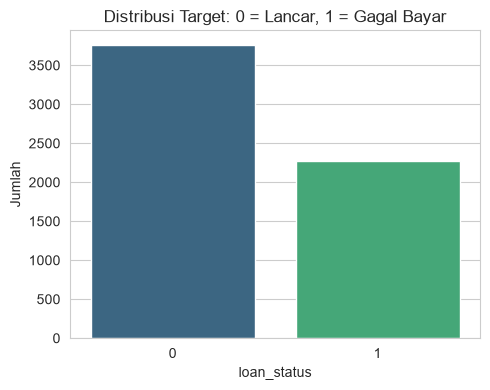

loan_status
0    0.623
1    0.377
Name: proportion, dtype: float64


In [47]:
# Visualisasi jumlah tiap kelas target
plt.figure(figsize=(5,4))
ax = sns.countplot(x='loan_status', data=df, palette='viridis')
ax.set_title('Distribusi Target: 0 = Lancar, 1 = Gagal Bayar')
ax.set_xlabel('loan_status'); ax.set_ylabel('Jumlah')
plt.tight_layout(); plt.show()

# Proporsi tiap kelas dalam persen
print(df['loan_status'].value_counts(normalize=True).round(3))

### 3.5 Distribusi Fitur Numerik
Melihat sebaran nilai & mendeteksi outlier (nilai ekstrem).

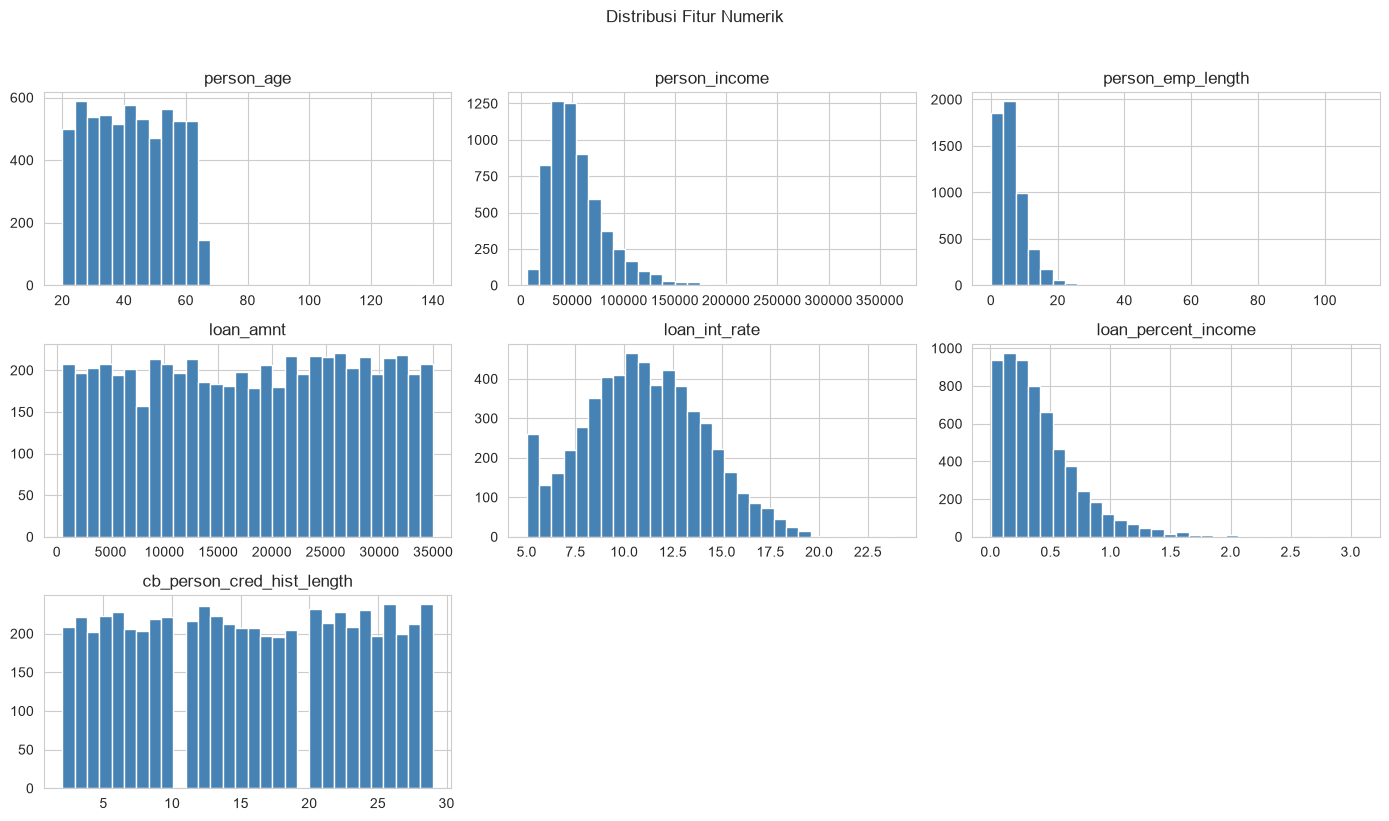

In [48]:
# Daftar kolom numerik (tanpa target)
num_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

# Histogram untuk tiap fitur numerik
df[num_cols].hist(figsize=(14, 8), bins=30, color='steelblue')
plt.suptitle('Distribusi Fitur Numerik', y=1.02)
plt.tight_layout(); plt.show()

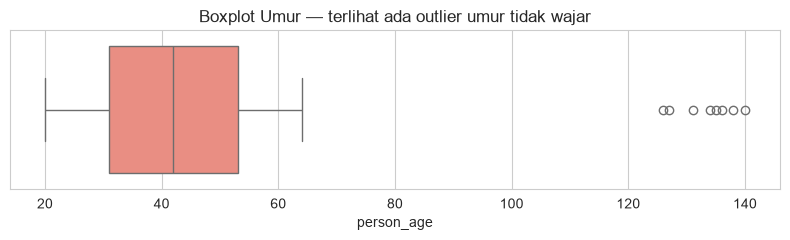

Umur maksimum di data: 140 (tidak wajar, akan dibersihkan)


In [49]:
# Boxplot 'person_age' untuk menyoroti outlier (mis. umur > 100 = tidak wajar)
plt.figure(figsize=(8,2.5))
sns.boxplot(x=df['person_age'], color='salmon')
plt.title('Boxplot Umur — terlihat ada outlier umur tidak wajar')
plt.tight_layout(); plt.show()

print('Umur maksimum di data:', df['person_age'].max(), '(tidak wajar, akan dibersihkan)')

### 3.6 Korelasi Antar Fitur Numerik
Melihat fitur mana yang saling berhubungan.

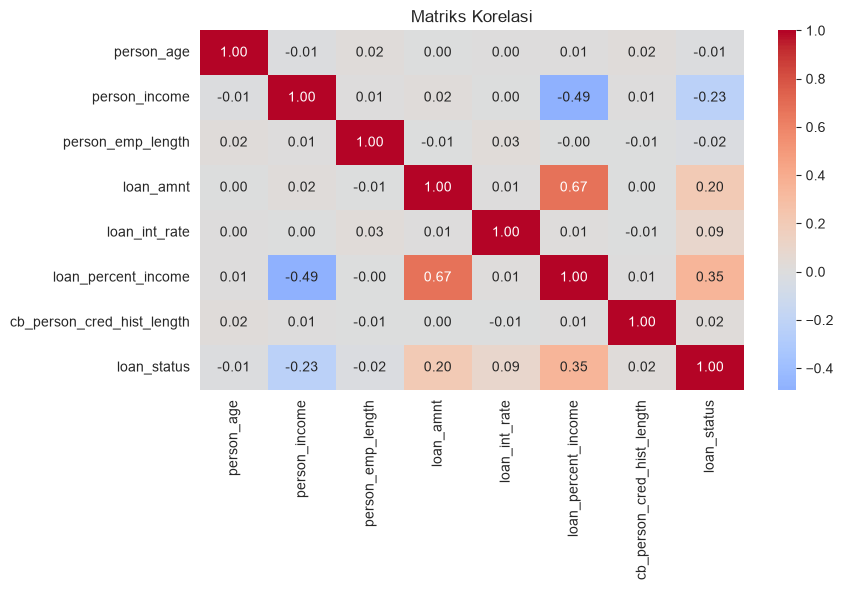

In [50]:
# Heatmap korelasi
plt.figure(figsize=(9,6))
corr = df[num_cols + ['loan_status']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriks Korelasi'); plt.tight_layout(); plt.show()

### 3.7 Fitur Kategorikal vs Target
Melihat bagaimana kategori memengaruhi kemungkinan gagal bayar.

C:\Users\Jonathan Benedict S\AppData\Local\Temp\ipykernel_25124\1418666144.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='loan_grade', y='loan_status', data=df, order=list('ABCDEFG'), palette='rocket')


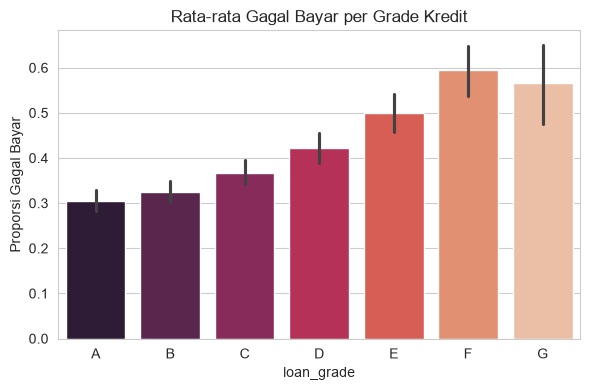

In [51]:
# Rata-rata target per kategori 'loan_grade' (grade kredit)
plt.figure(figsize=(6,4))
sns.barplot(x='loan_grade', y='loan_status', data=df, order=list('ABCDEFG'), palette='rocket')
plt.title('Rata-rata Gagal Bayar per Grade Kredit')
plt.ylabel('Proporsi Gagal Bayar'); plt.tight_layout(); plt.show()

## 4. Data Preprocessing
Sekarang kita bersihkan & siapkan data. Urutan langkah ini **HARUS SAMA** dengan yang nanti ditulis di `automate_JonathanBenedictSirait.py`.

Langkahnya:
1. Hapus baris duplikat.
2. Hapus outlier tidak wajar (umur & lama kerja).
3. Isi (impute) nilai kosong.
4. Encoding fitur kategorikal → angka.
5. Pisahkan fitur (X) dan target (y), lalu split train/test.
6. Standardisasi (scaling) fitur numerik.
7. Simpan hasil preprocessing.

### 4.1 Hapus Duplikat

In [52]:
# Salin data agar data asli tetap aman
data = df.copy()

before = len(data)
data = data.drop_duplicates().reset_index(drop=True)
print(f'Baris sebelum: {before} -> sesudah hapus duplikat: {len(data)}')

Baris sebelum: 6030 -> sesudah hapus duplikat: 6000


### 4.2 Hapus Outlier Tidak Wajar
Umur manusia realistis < 100 th, dan lama kerja tidak mungkin > umur.

In [53]:
# Buang baris dengan umur tidak wajar (>100) dan lama kerja tidak wajar (>60)
before = len(data)
data = data[(data['person_age'] <= 100) & (data['person_emp_length'].fillna(0) <= 60)]
data = data.reset_index(drop=True)
print(f'Baris sebelum: {before} -> sesudah buang outlier: {len(data)}')

Baris sebelum: 6000 -> sesudah buang outlier: 5987


### 4.3 Tangani Missing Value
Kolom numerik diisi dengan **median** (tahan terhadap outlier).

In [54]:
# Isi nilai kosong pada kolom numerik dengan median kolom tsb
for col in ['person_emp_length', 'loan_int_rate']:
    median_val = data[col].median()
    data[col] = data[col].fillna(median_val)
    print(f'{col}: nilai kosong diisi dengan median = {median_val}')

print('\nSisa nilai kosong:', data.isnull().sum().sum())

person_emp_length: nilai kosong diisi dengan median = 5.0
loan_int_rate: nilai kosong diisi dengan median = 10.91

Sisa nilai kosong: 0


### 4.4 Encoding Fitur Kategorikal
Model hanya mengerti angka, jadi teks kategori diubah ke angka.
- Kolom biner (`cb_person_default_on_file`: Y/N) → Label Encoding (0/1).
- Kolom multi-kategori → One-Hot Encoding.

In [55]:
# (a) Label encoding untuk kolom biner Y/N
data['cb_person_default_on_file'] = data['cb_person_default_on_file'].map({'N': 0, 'Y': 1})

# (b) One-Hot Encoding untuk kolom multi-kategori
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade']
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

# Ubah kolom hasil one-hot (True/False) menjadi 0/1
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

print('Jumlah kolom setelah encoding:', data.shape[1])
data.head(3)

Jumlah kolom setelah encoding: 23


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,28,25024,0.3,25327,12.97,1.012,0,7,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0
1,47,88947,1.4,21066,5.74,0.237,0,21,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,45,75037,8.0,23888,13.95,0.318,0,4,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


### 4.5 Pisahkan Fitur & Target, lalu Split Train/Test

In [56]:
# X = semua fitur, y = target
X = data.drop('loan_status', axis=1)
y = data['loan_status']

# Bagi data: 80% latih, 20% uji. stratify menjaga proporsi kelas tetap sama.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Data latih:', X_train.shape, '| Data uji:', X_test.shape)

Data latih: (4789, 22) | Data uji: (1198, 22)


### 4.6 Standardisasi (Scaling) Fitur Numerik
Menyamakan skala fitur numerik agar model tidak berat sebelah.
> **Penting:** scaler di-`fit` HANYA pada data latih, lalu dipakai (`transform`) ke data uji. Ini mencegah *data leakage*.

In [57]:
# Kolom numerik yang akan di-scaling
scale_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
              'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])  # fit + transform di train
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])       # transform saja di test

print('Contoh statistik setelah scaling (mean ~0, std ~1):')
X_train[scale_cols].describe().loc[['mean', 'std']].round(2)

Contoh statistik setelah scaling (mean ~0, std ~1):


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
mean,-0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### 4.7 Simpan Hasil Preprocessing
Gabungkan kembali & simpan ke folder `credit_scoring_preprocessing` untuk dipakai tahap modelling.

In [58]:
import os

# Gabungkan fitur + target kembali menjadi satu tabel train dan test
train_df = X_train.copy(); train_df['loan_status'] = y_train.values
test_df  = X_test.copy();  test_df['loan_status']  = y_test.values

# Buat folder output bila belum ada
out_dir = 'credit_scoring_preprocessing'
os.makedirs(out_dir, exist_ok=True)

# Simpan ke CSV
train_df.to_csv(f'{out_dir}/train.csv', index=False)
test_df.to_csv(f'{out_dir}/test.csv', index=False)

# Simpan juga gabungan lengkap (dipakai modelling.py yang men-split ulang sendiri)
full_df = pd.concat([train_df, test_df], ignore_index=True)
full_df.to_csv(f'{out_dir}/credit_scoring_clean.csv', index=False)

print('Hasil preprocessing tersimpan di folder:', out_dir)
print('train.csv:', train_df.shape, '| test.csv:', test_df.shape)

Hasil preprocessing tersimpan di folder: credit_scoring_preprocessing
train.csv: (4789, 23) | test.csv: (1198, 23)


## 5. Kesimpulan
Eksperimen selesai. Kita sudah:
- Memuat data mentah & memahaminya lewat EDA.
- Membersihkan duplikat, outlier, dan nilai kosong.
- Meng-encode kategori & men-scaling fitur numerik.
- Menyimpan dataset bersih yang siap dilatih.

**Langkah berikutnya:** semua langkah preprocessing di atas dikonversi menjadi fungsi otomatis di `automate_JonathanBenedictSirait.py` (Kriteria 1 - Skilled) dan dijalankan otomatis via GitHub Actions (Kriteria 1 - Advance).